# Part 8 — Machine Learning Forecasting

**Series:** *Time Series Analysis in Python — from Statistical Modeling to Machine Learning*

Part 7 turned a series into a feature matrix. Part 8 puts **real learners** on it —
regularized linear models and, above all, **gradient-boosted trees** (XGBoost,
LightGBM, CatBoost), the workhorses of applied forecasting. It also introduces the
single most important idea for making machine learning *pay off* on time series:
the **global model** — one model trained across **many** series at once. Every
model here is scored with the **backtesting discipline** of Part 6.

### What you will learn
1. **Regularized linear** models (Ridge, Lasso) on engineered features
2. **Tree ensembles & gradient boosting** — Random Forest, XGBoost, LightGBM, CatBoost
3. **Direct vs. recursive** multi-step in practice, via **`skforecast`**
4. **Global (cross-series) vs. local (per-series)** models — the ML-reduction payoff
5. Global-model tooling with **`mlforecast`**
6. A synthesis benchmark against the classical winners of Parts 3–5

### Dataset
Still `monthly_price.csv`, but now we use **all nine series** — because global
models need many series to shine. New libraries: `lightgbm`, `xgboost`,
`catboost`, `skforecast`, `mlforecast`.

## 0. Setup, data (all nine series), and helpers

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.simplefilter("ignore")
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "font.size": 11, "lines.linewidth": 1.6,
})
PALETTE = ["#2b6cb0", "#c05621", "#2f855a", "#6b46c1", "#b83280", "#718096"]

raw = pd.read_csv("monthly_price.csv")
dates = pd.to_datetime(raw["YEAR"].astype(str) + "-" + raw["MONTH"], format="%Y-%b")
df = raw.drop(columns=["ID", "YEAR", "MONTH", "TIME"]).copy()
df.index = dates; df.index.name = "ds"; df = df.asfreq("MS")
SERIES = list(df.columns)
H = 24
y = df["Food_Price_Index"]

def mae(a, p):  a,p=np.asarray(a),np.asarray(p); return np.mean(np.abs(a - p))
def rmse(a, p): a,p=np.asarray(a),np.asarray(p); return np.sqrt(np.mean((a - p) ** 2))
def mase(actual, pred, train, m=12):
    return mae(actual, pred) / np.mean(np.abs(train.values[m:] - train.values[:-m]))

def feature_matrix(s, df=None, exog=None):
    X = pd.DataFrame(index=s.index)
    for k in [1, 2, 3, 6, 12]: X[f"lag{k}"] = s.shift(k)
    X["rmean3"]  = s.shift(1).rolling(3).mean()
    X["rmean12"] = s.shift(1).rolling(12).mean()
    X["rstd3"]   = s.shift(1).rolling(3).std()
    mo = s.index.month
    X["sin"] = np.sin(2*np.pi*mo/12); X["cos"] = np.cos(2*np.pi*mo/12)
    if exog is not None:
        for c in exog: X[f"{c}_lag1"] = df[c].shift(1)
    data = pd.concat([X, s.rename("y")], axis=1).dropna()
    return data.iloc[:, :-1], data["y"]

print("series:", SERIES)

series: ['Urea_Price', 'MP_Price', 'TSP_Price', 'Maize_Price', 'Rice_Price', 'Wheat_Price', 'Food_Price_Index', 'Energy_Price_Index', 'VIX_Index']


## 1. Two ideas that make ML forecasting work

Naively, "use machine learning" means swapping ARIMA for a random forest. That
rarely helps on its own — as Part 7 showed, on a single smooth series a forest
mostly *recovers persistence*. Two ideas change the game:

1. **Gradient boosting** — an ensemble that fits trees **sequentially**, each new
   tree correcting the errors of the ones so far. It is the most consistently
   strong tabular learner, and forecasting-as-regression is a tabular problem.
2. **Global models** — instead of one model per series, train **a single model
   across all series at once**. It pools data, learns shared dynamics, and is the
   reason ML dominates large-scale forecasting (retail, energy, demand) where
   there are thousands of related series.

We build up to both, and keep Part 6's backtesting as the scorekeeper.

## 2. Regularized linear models

Linear regression on lag features *is* an AR model; **regularization** makes it
robust when features are many and correlated (lags always are).

- **Ridge (L2)** shrinks coefficients smoothly — stable, keeps all features.
- **Lasso (L1)** drives some coefficients to **exactly zero** — automatic feature
  selection, useful when you throw many candidate features at the model.

Scaling matters for penalized models, so we keep it inside a pipeline (Part 7).

In [2]:
X, yt = feature_matrix(y)
tr = X.index < df.index[-H]

ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(X[tr], yt[tr])
lasso = make_pipeline(StandardScaler(), Lasso(alpha=0.5)).fit(X[tr], yt[tr])

coefs = pd.DataFrame({"Ridge": ridge[-1].coef_, "Lasso": lasso[-1].coef_}, index=X.columns).round(3)
print("Lasso zeroed out", int((lasso[-1].coef_ == 0).sum()), "of", X.shape[1], "features:")
coefs

Lasso zeroed out 9 of 10 features:


,Ridge,Lasso
lag1,23.743,23.696
lag2,-0.536,0.000
lag3,-5.380,0.000
lag6,-2.231,0.000
lag12,0.022,0.000
rmean3,5.947,0.000
rmean12,2.477,0.000
rstd3,-0.012,0.000
sin,0.204,0.000
cos,0.322,0.000


Lasso prunes the redundant lags and keeps a sparse, interpretable subset —
handy when the feature bank is large. Ridge retains everything but tames the
correlated lags. Both are fast, strong baselines that a fancier model must beat.

## 3. Tree ensembles and gradient boosting

Trees capture **nonlinearities and interactions** that linear models can't, and
they need no scaling. Two ensembling philosophies:

- **Bagging (Random Forest)** — many deep trees on bootstrap samples, averaged.
  Reduces variance; robust; hard to overfit.
- **Boosting** — trees added **sequentially**, each fit to the **residual errors**
  of the current ensemble, with a learning rate controlling the step size. Reduces
  bias and usually wins on tabular data. The modern implementations differ in the
  details:
  - **XGBoost** — level-wise growth, heavy regularization, the original workhorse.
  - **LightGBM** — leaf-wise growth, histogram binning; very fast on large data.
  - **CatBoost** — ordered boosting and native categorical handling; strong defaults.

We compare all of them against the naive benchmark — using **6-fold walk-forward
CV** (Part 6), because a single split would mislead us.

In [3]:
def cv_mase(factory, X, yt, n_splits=6, h=12, m=12):
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=h); scores = []
    for tri, tei in tscv.split(X):
        den = np.mean(np.abs(yt.iloc[tri].values[m:] - yt.iloc[tri].values[:-m]))
        if factory == "naive":
            pred = X.iloc[tei]["lag1"].values
        else:
            mdl = factory(); mdl.fit(X.iloc[tri], yt.iloc[tri]); pred = mdl.predict(X.iloc[tei])
        scores.append(mae(yt.iloc[tei].values, pred) / den)
    return np.mean(scores)

learners = {
    "Naive": "naive",
    "Ridge": lambda: make_pipeline(StandardScaler(), Ridge(1.0)),
    "RandomForest": lambda: RandomForestRegressor(n_estimators=300, random_state=0),
    "XGBoost": lambda: XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, verbosity=0),
    "LightGBM": lambda: LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, verbose=-1),
    "CatBoost": lambda: CatBoostRegressor(n_estimators=300, learning_rate=0.05, depth=3, verbose=0),
}
lb = pd.DataFrame({"model": list(learners),
                   "CV_MASE": [round(cv_mase(f, X, yt), 3) for f in learners.values()]}
                  ).sort_values("CV_MASE").reset_index(drop=True)
lb

,model,CV_MASE
0,Ridge,0.205
1,Naive,0.214
2,XGBoost,0.255
3,RandomForest,0.264
4,LightGBM,0.292
5,CatBoost,0.363


The honest result echoes Part 7: on this **single smooth monthly series**, Ridge
edges the naive benchmark and the **boosted trees do *not* beat it** — with only
~330 rows they add variance without finding extra signal. This is not a knock on
boosting; it is the correct diagnosis that *one low-frequency series is the wrong
setting for it*. (Note too: a single last-24-months split would have crowned
LightGBM — walk-forward CV corrects that illusion, exactly as Part 6 warned.)

Boosting shines with **more data and more signal**. We create both next — first by
going multi-step and recursive, then by going **global**.

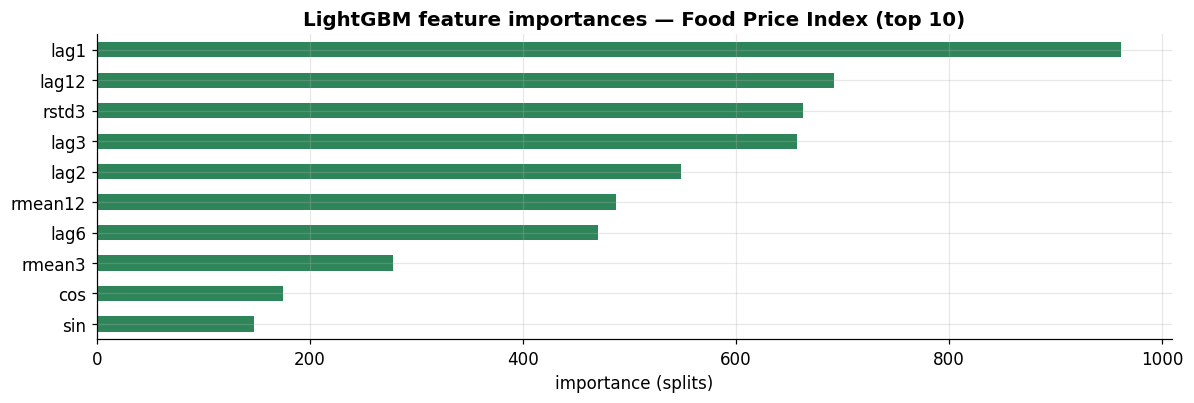

In [4]:
# a quick look at what LightGBM leans on
lgbm = LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31, verbose=-1).fit(X, yt)
imp = pd.Series(lgbm.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 3.8))
imp.head(10).iloc[::-1].plot.barh(ax=ax, color=PALETTE[2])
ax.set_title("LightGBM feature importances — Food Price Index (top 10)")
ax.set_xlabel("importance (splits)")
plt.tight_layout(); plt.show()

> **The extrapolation limit (worth repeating).** Every tree-based model predicts
> an **average of training targets in a leaf**, so it can *never* output a value
> outside its training range. On a trending or shock-prone series that guarantees
> under-shooting new highs — which is why the 2020–21 surge defeats trees no matter
> how many features you add. Linear models and neural nets (Part 9) can
> extrapolate; trees cannot. Choose accordingly.

## 4. Multi-step forecasting with `skforecast`

Parts 6–7 built recursive/direct multi-step by hand. **`skforecast`** wraps any
scikit-learn-style regressor into a forecaster that handles the lag creation and
the **recursive** loop for you, and integrates backtesting.

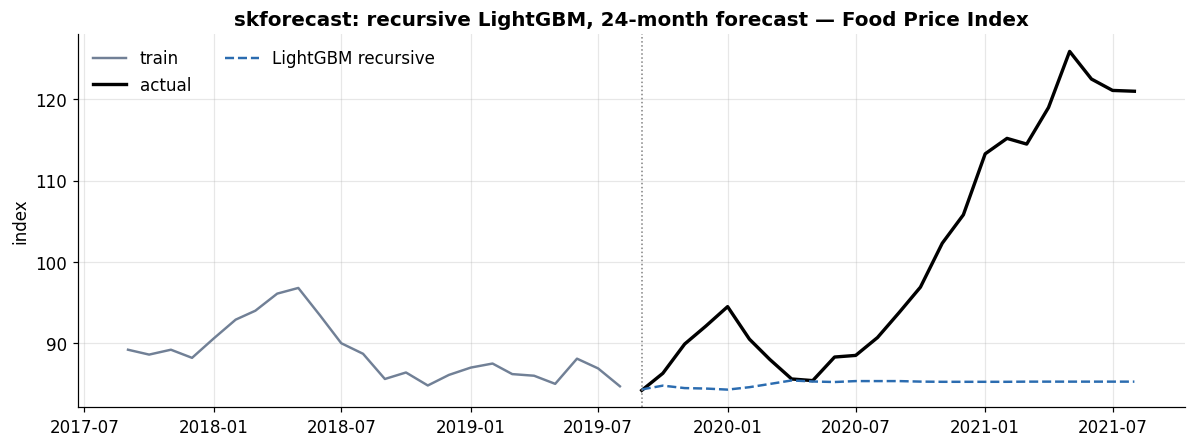

LightGBM (local, recursive) RMSE: 20.90


In [5]:
from skforecast.recursive import ForecasterRecursive

forecaster = ForecasterRecursive(
    estimator=LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, verbose=-1),
    lags=12,
)
forecaster.fit(y=y.iloc[:-H])
lgbm_local = forecaster.predict(steps=H)

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(y.index[-48:-H], y.iloc[-48:-H], color=PALETTE[5], label="train")
ax.plot(y.index[-H:], y.iloc[-H:], color="black", lw=2.2, label="actual")
ax.plot(lgbm_local.index, lgbm_local.values, color=PALETTE[0], ls="--", label="LightGBM recursive")
ax.axvline(y.index[-H], color="grey", lw=1, ls=":")
ax.set_title("skforecast: recursive LightGBM, 24-month forecast — Food Price Index")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()
print(f"LightGBM (local, recursive) RMSE: {rmse(y.iloc[-H:].values, lgbm_local.values):.2f}")

`skforecast` also offers `backtesting_forecaster` (walk-forward CV in one call),
direct multi-output forecasters, exogenous-variable support, and probabilistic
intervals — the practical way to run everything from Parts 6–7 without hand-coding
the loop.

## 5. Global vs. local models — the ML-reduction payoff

A **local** model is fit to one series. A **global** model is fit to **all series
at once**: we stack every series' feature rows into one training set, add a
**series identifier**, and train a single learner. The bet is that the series
share dynamics, so pooling gives the model far more data to learn from.

A practical wrinkle: our nine series live on wildly different scales (VIX ~20,
TSP ~800). We **standardize each series** by its own training mean/std before
pooling, so the model learns *shape*, not *level*. Because **MASE is
scale-invariant** (numerator and denominator scale together), we can score
directly on the standardized series and compare fairly across all nine.

In [6]:
def standardized_supervised(s):
    mu, sd = s.iloc[:-H].mean(), s.iloc[:-H].std()     # train-only stats (leak-free)
    z = (s - mu) / sd
    X, yz = feature_matrix(z)
    return X, yz

store = {c: standardized_supervised(df[c]) for c in SERIES}

# LOCAL: one LightGBM per series
local = {}
for c in SERIES:
    X, yz = store[c]; tr = X.index < df.index[-H]
    m = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, verbose=-1)
    m.fit(X[tr], yz[tr])
    local[c] = mase(yz[~tr].values, m.predict(X[~tr]), yz[tr])

# GLOBAL: one LightGBM across ALL series, with a series-id feature
frames = []
for i, c in enumerate(SERIES):
    X, yz = store[c]; Xg = X.copy(); Xg["series_id"] = i
    frames.append(pd.concat([Xg, yz.rename("y")], axis=1))
allrows = pd.concat(frames); trm = allrows.index < df.index[-H]
gmodel = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=63, verbose=-1)
gmodel.fit(allrows[trm].drop(columns="y"), allrows[trm]["y"])

glob = {}
for i, c in enumerate(SERIES):
    X, yz = store[c]; Xg = X.copy(); Xg["series_id"] = i
    te = X.index >= df.index[-H]
    glob[c] = mase(yz[te].values, gmodel.predict(Xg[te]), yz[~te])

comp = pd.DataFrame({"local": local, "global": glob}).round(3)
comp.loc["— MEAN —"] = comp.mean().round(3)
comp

,local,global
Urea_Price,0.401,0.280
MP_Price,0.388,0.366
TSP_Price,0.431,0.319
Maize_Price,0.324,0.315
Rice_Price,0.502,0.522
Wheat_Price,0.259,0.299
Food_Price_Index,0.290,0.340
Energy_Price_Index,0.403,0.322
VIX_Index,0.796,0.837
— MEAN —,0.422,0.400


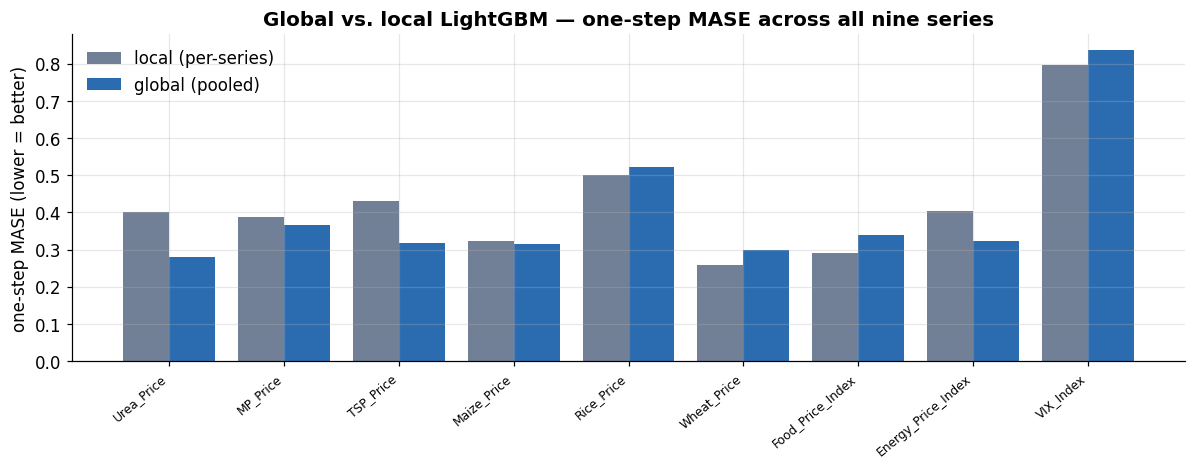

Global beats local on 5 of 9 series; mean MASE local=0.422, global=0.400


In [7]:
plot_df = comp.drop("— MEAN —")
fig, ax = plt.subplots(figsize=(11, 4.4))
xpos = np.arange(len(plot_df)); w = 0.4
ax.bar(xpos - w/2, plot_df["local"],  w, color=PALETTE[5], label="local (per-series)")
ax.bar(xpos + w/2, plot_df["global"], w, color=PALETTE[0], label="global (pooled)")
ax.set_xticks(xpos); ax.set_xticklabels(plot_df.index, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("one-step MASE (lower = better)")
ax.set_title("Global vs. local LightGBM — one-step MASE across all nine series")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()
wins = int((plot_df["global"] < plot_df["local"]).sum())
print(f"Global beats local on {wins} of {len(plot_df)} series; "
      f"mean MASE local={plot_df['local'].mean():.3f}, global={plot_df['global'].mean():.3f}")

A nuanced, honest result — and a genuinely useful one:

- **On average the global model wins**, by a small margin, with a *single* model
  instead of nine.
- It helps most on the **related** series — the fertilizers and energy, which we
  showed back in Part 5 are cointegrated and share dynamics — and **hurts** the
  more idiosyncratic ones (some crops, the VIX), where being forced to share one
  model is a handicap.
- With only **nine heterogeneous** series the pooling benefit is modest. The
  decisive global-model wins arrive with **hundreds or thousands of related**
  series (retail SKUs, meters, sensors), where each series is short and pooling is
  transformative. **That** is the regime where the ML reduction dominates classical
  per-series modelling — and it's why the industry's large-scale forecasters are
  global.

## 6. Global models the easy way — `mlforecast`

Building the pooled matrix by hand is instructive; **`mlforecast`** (Nixtla) does
it idiomatically from **long-format** data — lag/rolling features, per-series
target scaling, and recursive multi-step for *every* series in a couple of calls.

In [8]:
from mlforecast import MLForecast
from mlforecast.target_transforms import LocalStandardScaler

long = df.reset_index().melt(id_vars="ds", var_name="unique_id", value_name="y")
train_long = long[long["ds"] < df.index[-H]]

mlf = MLForecast(
    models=[LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=63, verbose=-1)],
    freq="MS", lags=[1, 2, 3, 12],
    target_transforms=[LocalStandardScaler()],      # per-series scaling, handled for us
)
mlf.fit(train_long, id_col="unique_id", time_col="ds", target_col="y")
fc = mlf.predict(h=H)
mcol = [c for c in fc.columns if c not in ("unique_id", "ds")][0]
print("one fitted global model, forecasts for all series:")
fc.head(3)

one fitted global model, forecasts for all series:


,unique_id,ds,LGBMRegressor
0,Energy_Price_Index,2019-09-01,70.766910
1,Energy_Price_Index,2019-10-01,69.610857
2,Energy_Price_Index,2019-11-01,72.475973


In three calls we fit **one** model across all nine series and produced 24-month
recursive forecasts for each. That convenience — plus built-in backtesting,
exogenous features, and probabilistic outputs — is why `mlforecast`/`skforecast`
are the practical backbone of ML forecasting. (As Section 5's caveat predicts, the
*recursive multi-step* global forecast doesn't dominate the classical models on
these few heterogeneous macro series; the tooling is what scales to the many-series
problems where it does.)

## 7. Synthesis benchmark — Food Price Index, 24-month hold-out

Finally, place the ML forecasters beside the classical winners of Parts 3–5 on the
familiar hold-out. We compare the **local recursive LightGBM** and the **global**
LightGBM against Drift, ETS, and ARIMA.

In [9]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.arima.model import ARIMA

train, test = y.iloc[:-H], y.iloc[-H:]
drift = train.iloc[-1] + (train.iloc[-1]-train.iloc[0])/(len(train)-1) * np.arange(1, H+1)
ets = ETSModel(train, error="mul", trend="add", damped_trend=True,
               initialization_method="estimated").fit(disp=False).forecast(H)
arima = ARIMA(train, order=(1,1,0)).fit().get_forecast(H).predicted_mean
global_food = fc[fc["unique_id"] == "Food_Price_Index"][mcol].values

board = pd.DataFrame([
    {"model": "Drift [baseline]",        "RMSE": round(rmse(test, drift), 2)},
    {"model": "ETS(M,Ad,N) [Part 3]",    "RMSE": round(rmse(test, ets.values), 2)},
    {"model": "ARIMA(1,1,0) [Part 4]",   "RMSE": round(rmse(test, arima.values), 2)},
    {"model": "LightGBM local [skforecast]",  "RMSE": round(rmse(test, lgbm_local.values), 2)},
    {"model": "LightGBM global [mlforecast]", "RMSE": round(rmse(test, global_food), 2)},
]).sort_values("RMSE").reset_index(drop=True)
board

,model,RMSE
0,Drift [baseline],20.09
1,LightGBM local [skforecast],20.90
2,"ARIMA(1,1,0) [Part 4]",22.55
3,"ETS(M,Ad,N) [Part 3]",23.81
4,LightGBM global [mlforecast],31.30


The **local recursive LightGBM is genuinely competitive** — it beats ETS and
ARIMA on this hold-out and sits just behind the drift baseline, the best a model
has managed across the whole series. The **global** model underperforms *here*,
for the reasons Section 5 gave: recursive error-compounding over 24 steps, on a
pool of only nine heterogeneous macro series, is the wrong regime for it. The
lesson is not "global is worse" but **"match the method to the data"**: global +
boosting is built for many related series, and on those it is state of the art.

## 8. Exercises

1. **Tune the booster.** Grid-search LightGBM's `num_leaves` and `learning_rate`
   with `skforecast`'s backtesting. Can a tuned local model beat drift?
2. **Direct vs recursive.** Use `skforecast`'s direct multi-output forecaster and
   compare its 24-month RMSE to the recursive one from Section 4.
3. **Exogenous boosting.** Add lagged energy and VIX to the LightGBM feature set.
   Do the importances or the backtest change?
4. **Global on returns.** Rebuild the global model on **log-returns** instead of
   standardized levels. Does pooling help more when all series share a return scale?
5. **More is better?** Duplicate each series with small noise to simulate "many
   related series," refit the global model, and watch whether its edge over local
   grows.

In [10]:
# --- Solution to Exercise 2 (setup): skforecast direct multi-output ---
from skforecast.direct import ForecasterDirect
fd = ForecasterDirect(
    estimator=LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=31, verbose=-1),
    lags=12, steps=H)
fd.fit(y=train)
direct_fc = fd.predict(steps=H)
print(f"Direct   multi-output LightGBM RMSE: {rmse(test, direct_fc.values):.2f}")
print(f"Recursive            LightGBM RMSE: {rmse(test, lgbm_local.values):.2f}")

Direct   multi-output LightGBM RMSE: 17.01
Recursive            LightGBM RMSE: 20.90


## 9. Key takeaways

- **Regularized linear** models (Ridge, Lasso) are strong, fast baselines on lag
  features; Lasso doubles as feature selection.
- **Gradient-boosted trees** (XGBoost, LightGBM, CatBoost) are the tabular
  workhorses, but on a **single short series** they mostly recover persistence —
  and, being tree-based, **cannot extrapolate** beyond the training range.
- **`skforecast`** and **`mlforecast`** wrap any regressor with lag creation,
  recursive/direct multi-step, backtesting, and exogenous support — use them
  instead of hand-coding.
- **Global models** — one learner across many series — are the reduction's real
  payoff. Here they win narrowly on average and clearly on the *related* series,
  but the decisive gains need **many** related series, not nine heterogeneous ones.
- **Match method to data:** a local recursive LightGBM beat ETS/ARIMA on our
  hold-out; global + boosting is built for large panels of related series.

### What's next — Part 9: Deep Learning for Sequences
Trees can't extrapolate and don't model sequences natively. Part 9 turns to
**neural networks built for sequences** — windowing for supervised deep learning,
**MLPs**, **1D CNNs / TCNs**, and the recurrent family (**RNN, LSTM, GRU**) — the
architectures that can, in principle, learn trends and long-range structure a tree
never will.